# Librerias y dependencias

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os

import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall,Precision

# carga de datos
se cargan los datos ya separados en test y prueba

In [2]:
# Ruta al archivo .h5 en el dataset de Kaggle
train_data_path = '/kaggle/input/test-train/train_data.h5'
test_data_path = '/kaggle/input/test-train/test_data.h5'

# Cargar los datos
train_data = pd.read_hdf(train_data_path)
test_data = pd.read_hdf(test_data_path)
train_data.head()

,ID,Patient Age,Patient Sex,target,filename,diagnostic,binary_target
6306,4584,42,Male,1,4584_left.jpg,D,0
2244,3126,41,Male,0,3126_right.jpg,N,1
1716,2553,54,Female,0,2553_right.jpg,N,1
6368,4653,68,Male,1,4653_left.jpg,D,0
4970,2618,58,Male,0,2618_left.jpg,N,1


Se separan los datos del objetivo 

In [ ]:
X_train, y_train = train_data.drop(columns=['target']), train_data['target']
X_test, y_test = test_data.drop(columns=['target']), test_data['target']

In [4]:
print(y_train.value_counts())

target
0    2298
1    1286
7     566
3     234
2     227
4     213
6     186
5     103
Name: count, dtype: int64


Se cargan las imágenes y se confirma que estas se puedan abrir

In [ ]:

def load_images(filenames):
    images = []
    # Definir la ruta base en Kaggle
    image_folder_path = '/kaggle/input/ocular-disease-recognition-odir5k/preprocessed_images'

    for filename in filenames:
        img_path = os.path.join(image_folder_path, filename)
        img = cv2.imread(img_path)
        
        if img is not None:
            # Convertir de BGR a RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
        else:
            print(f"Warning: La imagen {filename} no se pudo cargar.")

    return np.array(images)

X_train_images = load_images(X_train['filename'])

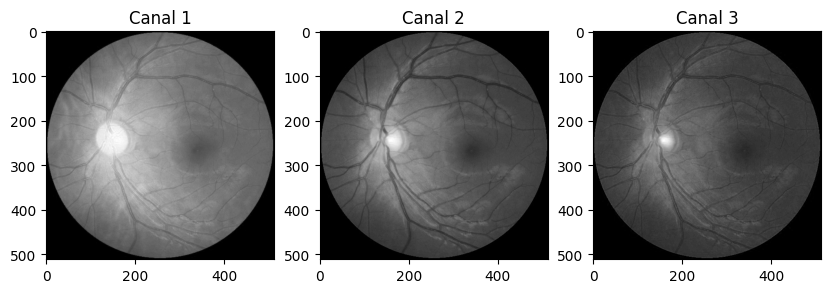

In [ ]:

fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(X_train_images[0][:,:,0], cmap='gray')
axs[0].set_title('Canal 1')
axs[1].imshow(X_train_images[0][:,:,1], cmap='gray')
axs[1].set_title('Canal 2')
axs[2].imshow(X_train_images[0][:,:,2], cmap='gray')
axs[2].set_title('Canal 3')
plt.show()

# preparacion del Modelo

definición del modelo

In [ ]:
def convolutional_model(input_shape):
    # define la entrada del modelo
    input_img = tf.keras.Input(shape=input_shape)
    
    # Primera capa convolucional
    Z1 = tf.keras.layers.Conv2D(
        filters=16, 
        kernel_size=(3,3), 
        padding='same', 
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
    )(input_img)
    
    BN1 = tf.keras.layers.BatchNormalization()(Z1)
    A1 = tf.keras.layers.Activation('relu')(BN1)
    P1 = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), 
        strides=(2, 2), 
        padding='same'
    )(A1)
    D1 = tf.keras.layers.Dropout(0.1)(P1)

    # Segunda capa convolucional
    Z2 = tf.keras.layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3), 
        padding='same', 
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
    )(D1)
    BN2 = tf.keras.layers.BatchNormalization()(Z2)
    A2 = tf.keras.layers.Activation('relu')(BN2)
    P2 = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), 
        strides=(2, 2), 
        padding='same'
    )(A2)
    D2 = tf.keras.layers.Dropout(0.1)(P2)

    # Tercera capa convolucional
    Z3 = tf.keras.layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3), 
        padding='same', 
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
    )(D2)
    BN3 = tf.keras.layers.BatchNormalization()(Z3)
    A3 = tf.keras.layers.Activation('relu')(BN3)
    P3 = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), 
        strides=(2, 2), 
        padding='same'
    )(A3)
    D3 = tf.keras.layers.Dropout(0.1)(P3)

    # cuarta capa convolucional
    Z4 = tf.keras.layers.Conv2D(
        filters=16, 
        kernel_size=(3, 3), 
        padding='same', 
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
    )(D3)
    BN4 = tf.keras.layers.BatchNormalization()(Z4)
    A4 = tf.keras.layers.Activation('relu')(BN4)
    P4 = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), 
        strides=(2, 2), 
        padding='same'
    )(A4)
    D4 = tf.keras.layers.Dropout(0.1)(P4) 

    # aplanar las capas
    F = tf.keras.layers.Flatten()(D4)
    
    # capa totalmente conectada (dense)
    FC = tf.keras.layers.Dense(
        256, 
        activation='relu', 
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
    )(F)
    FC_Dropout = tf.keras.layers.Dropout(0.4)(FC) 

    # Dense capa de salida
    outputs = tf.keras.layers.Dense(
        8, 
        activation='softmax',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)  # L2 regularization
    )(FC_Dropout)
    
    # Model construction
    model = tf.keras.Model(inputs=input_img, outputs=outputs)
    
    return model 

# Define la forma de la entrada y crea el modelo
input_shape = (512, 512, 3)
model = convolutional_model(input_shape)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 512, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 512, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512, 512, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,56

 Total params: 4,215,960 (16.08 MB)

 Trainable params: 4,215,768 (16.08 MB)

 Non-trainable params: 192 (768.00 B)

Se reinicia el índice de y_train

In [8]:
y_train = y_train.reset_index(drop=True)
print(y_train.head())

0    1
1    0
2    0
3    1
4    0
Name: target, dtype: int64


se aumentan las imagenes de las categorias menos representadas a traves de copias modificadas de las originales

In [9]:
import tensorflow as tf
import numpy as np

def augment_images(images, labels):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        if label not in [0, 1, 7]: 
            h_flip_img = tf.image.flip_left_right(img)
            v_flip_img = tf.image.flip_up_down(img)

            h_flip_sat_img = tf.image.random_saturation(h_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(h_flip_sat_img)
            augmented_labels.append(label)

            v_flip_sat_img = tf.image.random_saturation(v_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(v_flip_sat_img)
            augmented_labels.append(label)

            hv_flip_img = tf.image.flip_left_right(tf.image.flip_up_down(img))
            v_flip_sat_img = tf.image.random_saturation(v_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(hv_flip_img)
            augmented_labels.append(label)

        if label in [7]:
            h_flip_img = tf.image.flip_left_right(img)
            h_flip_sat_img = tf.image.random_saturation(h_flip_img, lower=0.6, upper=1.4)
            augmented_images.append(h_flip_sat_img)
            augmented_labels.append(label)

            

    return np.array(augmented_images), np.array(augmented_labels)

# Ejemplo de uso
X_train_augmented, y_train_augmented = augment_images(X_train_images, y_train)

Ejemplo de imágenes generadas 

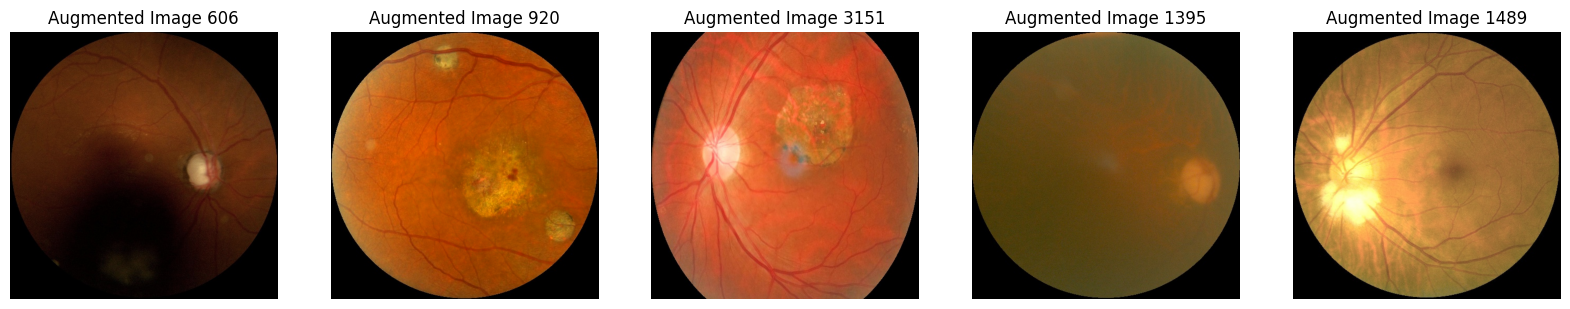

In [ ]:
import matplotlib.pyplot as plt

# Numero de imagenes a graficar
num_images_to_plot = 5

# grafica de las imagenes
fig, axes = plt.subplots(1, num_images_to_plot, figsize=(20, 20))
for i in range(num_images_to_plot):
    random_index = np.random.randint(0, len(X_train_augmented))
    axes[i].imshow(X_train_augmented[random_index])
    axes[i].set_title(f"Augmented Image {random_index}")
    axes[i].axis('off')

plt.show()

In [11]:
print(X_train_augmented.shape[0])
print(X_train.shape[0])

3455
5113


Se extrae un set de validación del set de entrenamiento 

In [12]:
# Filter the indices of class 0
class_0_indices = y_train[y_train == 0].index
class_1_indices = y_train[y_train == 1].index

# Randomly select 1000 indices from class 0
validation_indices_0 = np.random.choice(class_0_indices, 1100, replace=False)
validation_indices_1 = np.random.choice(class_1_indices, 300, replace=False)

validation_indices = np.concatenate([validation_indices_0, validation_indices_1])

# Create validation set
X_val = X_train_images[validation_indices]
y_val = y_train[validation_indices]

# Remove the selected indices from the training set
X_train_images = np.delete(X_train_images, validation_indices, axis=0)
y_train = y_train.drop(validation_indices).reset_index(drop=True)

print(f"Validation set size: {X_val.shape[0]}")
print(f"Training set size after removal: {X_train_images.shape[0]}")

Validation set size: 1400
Training set size after removal: 3713


Se revisa la distribución de la base de datos para entrenamiento con las imágenes originales y modificadas

In [13]:
# Class distribution of non-augmented dataset
print("Class distribution in y_train:")
print(y_train.value_counts())

# Class distribution of augmented dataset
unique, counts = np.unique(y_train_augmented, return_counts=True)
augmented_class_distribution = dict(zip(unique, counts))
print("\nClass distribution in y_train_augmented:")
print(augmented_class_distribution)

# Combine the counts
combined_counts = y_train.value_counts().to_dict()
for key, value in augmented_class_distribution.items():
    if key in combined_counts:
        combined_counts[key] += value
    else:
        combined_counts[key] = value

print("\nCombined class distribution:")
print(combined_counts)

Class distribution in y_train:
target
0    1198
1     986
7     566
3     234
2     227
4     213
6     186
5     103
Name: count, dtype: int64

Class distribution in y_train_augmented:
{2: 681, 3: 702, 4: 639, 5: 309, 6: 558, 7: 566}

Combined class distribution:
{0: 1198, 1: 986, 7: 1132, 3: 936, 2: 908, 4: 852, 6: 744, 5: 412}


Se convinan los datos originales con los generados

In [14]:
# Concatenate the original and augmented datasets
X_train_combined = np.concatenate((X_train_images, X_train_augmented), axis=0)
y_train_combined = np.concatenate((y_train, y_train_augmented), axis=0)

# Shuffle the combined dataset
indices = np.arange(X_train_combined.shape[0])
np.random.shuffle(indices)
X_train_combined = X_train_combined[indices]
y_train_combined = y_train_combined[indices]

# entrenamiento del modelo
se define una condicion de parada temprana, se crea el modelo y final mente se entrna

In [15]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision

# Define el early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitorea la pérdida en el conjunto de validación
    patience=100,               # Número de épocas sin mejora antes de detener
    restore_best_weights=False # Restaura los mejores pesos encontrados durante el entrenamiento
)

# Compila el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']  # Añade precisión como métrica
)

# Entrena el modelo con early stopping
history = model.fit(
    X_train_combined,
    y_train_combined,
    epochs=120,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping]  # Añade el early stopping como callback
    #class_weight=class_weights,
)



Epoch 1/120


I0000 00:00:1731948493.291465    4216 service.cc:145] XLA service 0x782b78005530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731948493.291520    4216 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  3/180 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.0851 - loss: 16.8537

I0000 00:00:1731948506.949971    4216 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.1676 - loss: 10.1210 - val_accuracy: 0.2622 - val_loss: 4.3441
Epoch 2/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.1954 - loss: 3.9670 - val_accuracy: 0.1262 - val_loss: 3.1689
Epoch 3/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.2149 - loss: 2.9209 - val_accuracy: 0.1374 - val_loss: 2.6439
Epoch 4/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.2216 - loss: 2.4549 - val_accuracy: 0.1987 - val_loss: 2.3508
Epoch 5/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.2135 - loss: 2.2731 - val_accuracy: 0.2252 - val_loss: 2.2295
Epoch 6/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.2158 - loss: 2.1808 - val_accuracy: 0.2350 - val_loss: 2.1362
Epoch 7/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.2239 - loss: 2.1325 - val_accuracy: 0.2392 - val_loss: 2.1152
Epoch 8/120
180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.2292 - loss: 2.0813 - va

# resultados Modelo
se cargan las imagenes del set de prueba

In [ ]:
#cargamos las imagenes de prueba
X_test_images = load_images(X_test['filename'])

se corre el modelo con los datos de prueba y se grafica el resultado en una matriz de confusión.

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step


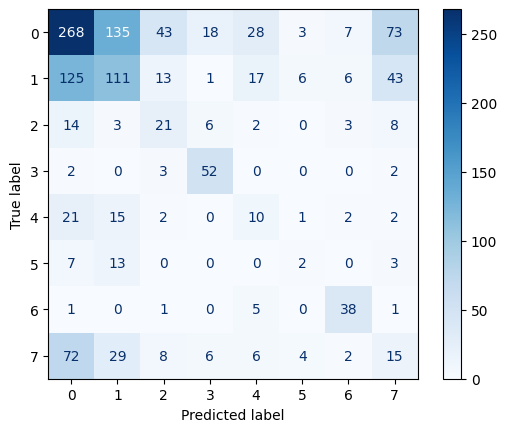

'\nNormal (N),\nDiabetes (D),\nGlaucoma (G), need augm\nCataract (C),\nAge related Macular Degeneration (A),\nHypertension (H),\nPathological Myopia (M),\nOther diseases/abnormalities (O)\n'

In [ ]:
#mostramos la matris de confución
y_pred = model.predict(X_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


"""
Normal (N),
Diabetes (D),
Glaucoma (G), need augm
Cataract (C),
Age related Macular Degeneration (A),
Hypertension (H),
Pathological Myopia (M),
Other diseases/abnormalities (O)
"""

In [18]:
X_test_images.shape

(1279, 512, 512, 3)

In [19]:
y_test.shape

(1279,)

Se evalua la presicióndel modelo

In [ ]:
#se muestra la precicion del modelo actual y 
loss, accuracy = model.evaluate(X_test_images, np.array(y_test))
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4062 - loss: 1.7589
Loss: 1.7670499086380005
Accuracy: 0.4042220413684845


Se selecciona una imagen al azar para observar los filtros y así intentar entender como el modelo llego a ese resultado

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


/tmp/ipykernel_4148/3837263661.py:32: RuntimeWarning: invalid value encountered in divide
  x /= x.std()
/tmp/ipykernel_4148/3837263661.py:35: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')
/tmp/ipykernel_4148/3837263661.py:32: RuntimeWarning: divide by zero encountered in divide
  x /= x.std()


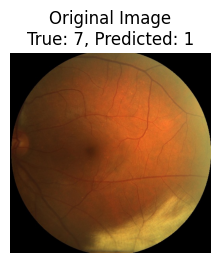

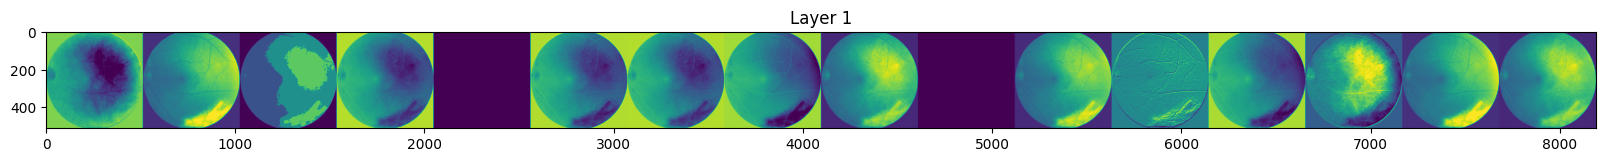

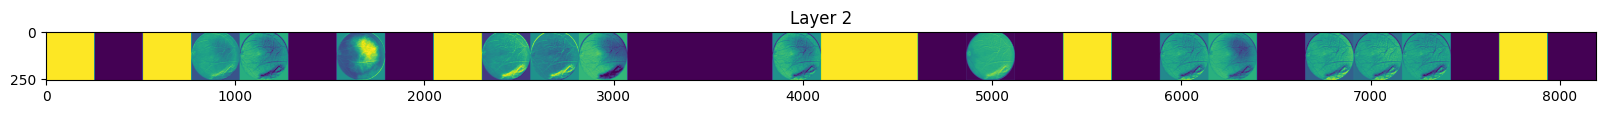

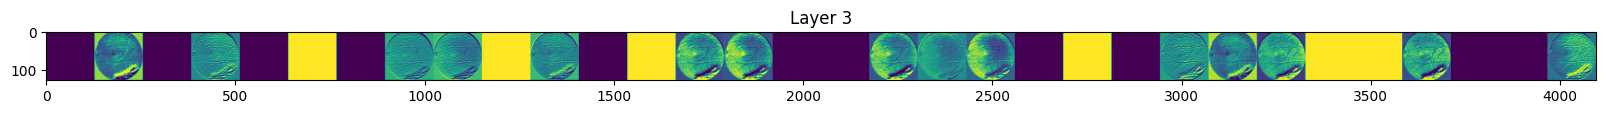

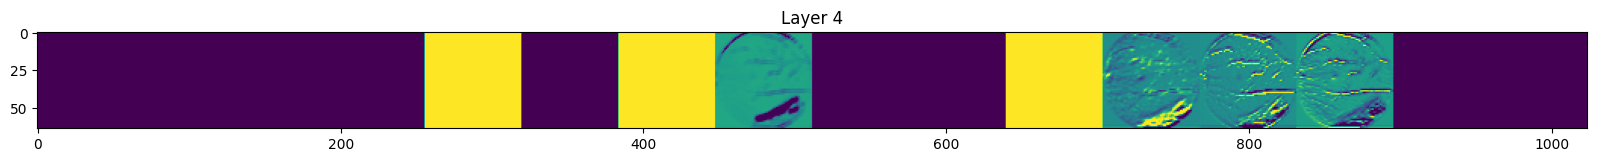

In [21]:
# Select an image from the test set
image_index = np.random.randint(0, len(X_test_images))
image = X_test_images[image_index]

# Get the true class and predicted class
true_class = y_test.iloc[image_index]
predicted_class = y_pred_classes[image_index]

# Create a model that outputs the activations of each convolutional layer
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

# Get the activations
activations = activation_model.predict(np.expand_dims(image, axis=0))

# Plot the original image
plt.figure(figsize=(15, 15))
plt.subplot(1, len(activations) + 1, 1)
plt.imshow(image)
plt.title(f'Original Image\nTrue: {true_class}, Predicted: {predicted_class}')
plt.axis('off')

# Plot the activations of each convolutional layer
for i, activation in enumerate(activations):
    num_filters = activation.shape[-1]
    size = activation.shape[1]
    display_grid = np.zeros((size, size * num_filters))
    
    for j in range(num_filters):
        x = activation[0, :, :, j]
        x -= x.mean()
        x /= x.std()
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        display_grid[:, j * size : (j + 1) * size] = x
    
    scale = 20. / num_filters
    plt.figure(figsize=(scale * num_filters, scale))
    plt.title(f'Layer {i + 1}')
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

plt.show()

Se revisa la precisión del modelo por categoria

In [22]:
from sklearn.metrics import classification_report

# Print the classification report
report = classification_report(y_test, y_pred_classes, target_names=[str(i) for i in np.unique(y_train)])
print(report)

              precision    recall  f1-score   support

           0       0.53      0.47      0.49       575
           1       0.36      0.34      0.35       322
           2       0.23      0.37      0.28        57
           3       0.63      0.88      0.73        59
           4       0.15      0.19      0.17        53
           5       0.12      0.08      0.10        25
           6       0.66      0.83      0.73        46
           7       0.10      0.11      0.10       142

    accuracy                           0.40      1279
   macro avg       0.35      0.41      0.37      1279
weighted avg       0.41      0.40      0.40      1279



In [ ]:
#se guarda el modelo entrenado en formato h5
model.save('dl_model.h5')